In [1]:


import os

image_dir = "/kaggle/input/datasets/peeyushsahu123/pcb-dataset/val/labels"

num_images = len(os.listdir(image_dir))

print("Total number of images:", num_images)

Total number of images: 812


In [2]:
import os
from PIL import Image
from collections import Counter

image_dir = "/kaggle/input/datasets/peeyushsahu123/pcb-dataset/train/images"

sizes = []

for file in os.listdir(image_dir):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        img_path = os.path.join(image_dir, file)
        
        try:
            with Image.open(img_path) as img:
                sizes.append(img.size)   # (width, height)
        except:
            continue

# Count occurrences of each size
size_counts = Counter(sizes)

# Print results
for size, count in size_counts.items():
    print(f"{size[0]}x{size[1]} : {count} images")

640x640 : 1720 images
600x600 : 4253 images
601x601 : 2117 images


In [3]:
from collections import Counter

label_dir = "/kaggle/input/datasets/peeyushsahu123/pcb-dataset/train/labels"

# Your class names
names = {
    2: "missing_hole", 
    0: "mouse_bite", 
    4: "open_circuit", 
    3: "short_circuit", 
    1: "spur", 
    5: "spurious_copper"
}

class_counts = Counter()

# Read all label files
for file in os.listdir(label_dir):
    if file.endswith(".txt"):
        file_path = os.path.join(label_dir, file)
        
        with open(file_path, "r") as f:
            lines = f.readlines()
            
            for line in lines:
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

# Print results
print("📊 Class Distribution:\n")

for class_id, count in class_counts.items():
    print(f"{names[class_id]} ({class_id}) : {count}")

📊 Class Distribution:

missing_hole (2) : 3076
open_circuit (4) : 2591
short_circuit (3) : 2507
mouse_bite (0) : 2831
spurious_copper (5) : 2983
spur (1) : 2889


In [4]:
data_yaml = """
path: /kaggle/input/datasets/peeyushsahu123/pcb-dataset

train: train/images
val: val/images
test: test/images

names:
  0: mouse_bite
  1: spur
  2: missing_hole
  3: short_circuit
  4: open_circuit
  5: spurious_copper
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(data_yaml)

In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.9 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e1315f5eb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [7]:
from ultralytics import YOLO
import os

# Load trained model
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

# Dataset path (correct as you said)
img_path = "/kaggle/input/datasets/peeyushsahu123/pcb-dataset/test/images"

# Pick few images
sample_imgs = os.listdir(img_path)[:5]
sample_imgs

['d1_rotation_90_light_08_short_02_4_600.jpg',
 'd1_rotation_270_light_05_mouse_bite_06_1_600.jpg',
 'd1_rotation_90_light_10_open_circuit_05_3_600.jpg',
 'd1_rotation_270_light_09_mouse_bite_06_1_600.jpg',
 'd1_l_light_05_open_circuit_01_2_600.jpg']

In [8]:
model.predict(
    source=[os.path.join(img_path, i) for i in sample_imgs],
    save=True,
    save_txt=True,
    conf=0.2,
    project="/kaggle/working/runs/detect",
    name="predict",
    exist_ok=True   # 🔥 THIS LINE IS KEY
)


0: 640x640 1 short_circuit, 7.6ms
1: 640x640 2 mouse_bites, 7.6ms
2: 640x640 1 open_circuit, 7.6ms
3: 640x640 2 mouse_bites, 7.6ms
4: 640x640 1 open_circuit, 7.6ms
Speed: 3.9ms preprocess, 7.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict
5 labels saved to /kaggle/working/runs/detect/predict/labels


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'mouse_bite', 1: 'spur', 2: 'missing_hole', 3: 'short_circuit', 4: 'open_circuit', 5: 'spurious_copper'}
 obb: None
 orig_img: array([[[  0,   2,   2],
         [  0,   1,   1],
         [  0,   2,   0],
         ...,
         [  0,  19,   0],
         [  0,  20,   0],
         [  0,  20,   0]],
 
        [[173, 185, 187],
         [176, 188, 190],
         [180, 190, 190],
         ...,
         [ 83, 132,  70],
         [ 90, 141,  79],
         [ 84, 136,  72]],
 
        [[153, 165, 171],
         [166, 178, 184],
         [179, 190, 194],
         ...,
         [ 70, 139,  52],
         [ 77, 149,  59],
         [ 65, 137,  47]],
 
        ...,
 
        [[ 70, 167,  33],
         [ 57, 155,  19],
         [ 51, 150,  11],
         ...,
         [103, 134,  55],
         [105, 132,  59],
         [124, 152,  82]],
 
        [[ 65, 

In [9]:
pred_path = "/kaggle/working/runs/detect/predict/labels"

print("Prediction files:", os.listdir(pred_path)[:10])

Prediction files: ['image2.txt', 'image3.txt', 'image1.txt', 'image0.txt', 'image4.txt']


In [10]:
import cv2
import matplotlib.pyplot as plt

gt_path = "/kaggle/input/datasets/peeyushsahu123/pcb-dataset/test/labels"

classes = ['mouse_bite','spur','missing_hole','short_circuit','open_circuit','spurious_copper']


def draw_boxes(image, label_file, color, label_type):
    h, w, _ = image.shape

    if not os.path.exists(label_file):
        print(f"No {label_type} for:", os.path.basename(label_file))
        return image

    with open(label_file, 'r') as f:
        for line in f.readlines():
            parts = list(map(float, line.split()))
            
            cls, x, y, bw, bh = parts[:5]  # ignore confidence if present

            # YOLO → pixel
            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            # Clamp (fix negative values)
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(w, x2)
            y2 = min(h, y2)

            label = classes[int(cls)] + f" ({label_type})"

            cv2.rectangle(image, (x1,y1), (x2,y2), color, 2)
            cv2.putText(image, label, (x1, max(10, y1-5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return image

sample_imgs: 5
pred_imgs: 5

Processing: image0.jpg
GT: /kaggle/input/datasets/peeyushsahu123/pcb-dataset/test/labels/d1_rotation_90_light_08_short_02_4_600.txt
Pred: /kaggle/working/runs/detect/predict/labels/image0.txt


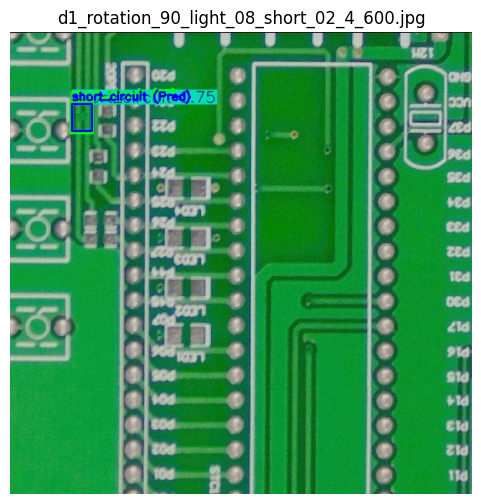


Processing: image1.jpg
GT: /kaggle/input/datasets/peeyushsahu123/pcb-dataset/test/labels/d1_rotation_270_light_05_mouse_bite_06_1_600.txt
Pred: /kaggle/working/runs/detect/predict/labels/image1.txt


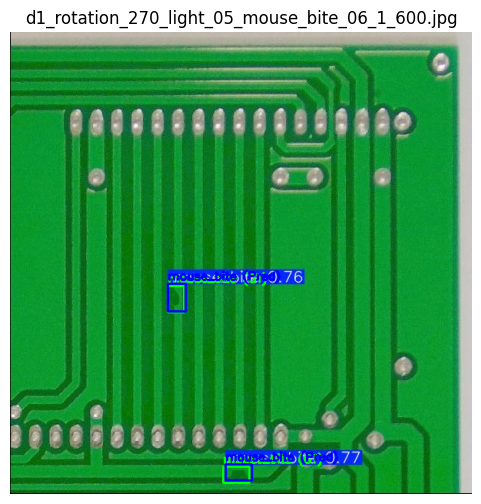


Processing: image2.jpg
GT: /kaggle/input/datasets/peeyushsahu123/pcb-dataset/test/labels/d1_rotation_90_light_10_open_circuit_05_3_600.txt
Pred: /kaggle/working/runs/detect/predict/labels/image2.txt


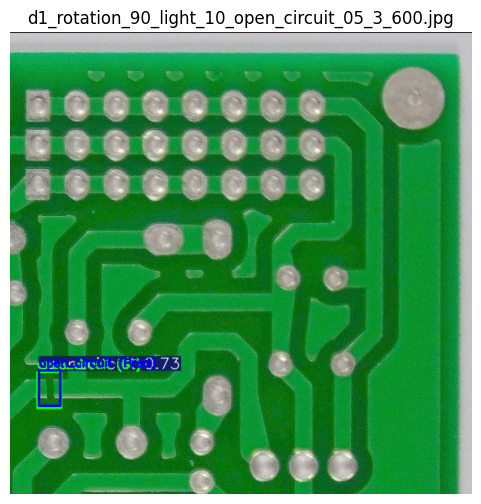


Processing: image3.jpg
GT: /kaggle/input/datasets/peeyushsahu123/pcb-dataset/test/labels/d1_rotation_270_light_09_mouse_bite_06_1_600.txt
Pred: /kaggle/working/runs/detect/predict/labels/image3.txt


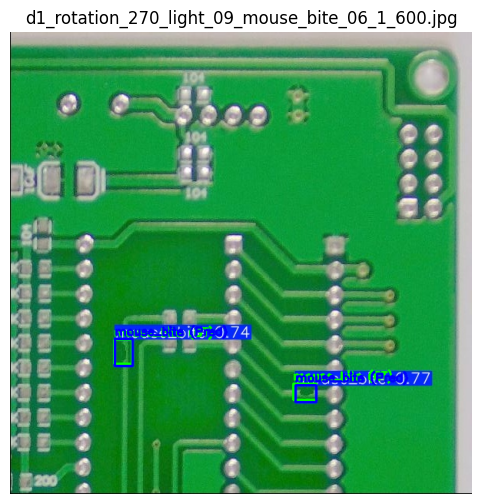


Processing: image4.jpg
GT: /kaggle/input/datasets/peeyushsahu123/pcb-dataset/test/labels/d1_l_light_05_open_circuit_01_2_600.txt
Pred: /kaggle/working/runs/detect/predict/labels/image4.txt


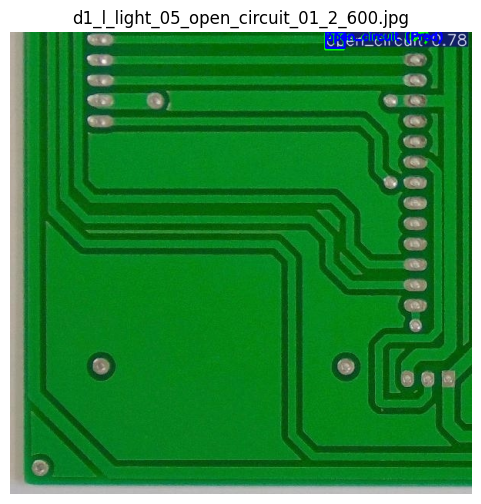

In [11]:
pred_img_path = "/kaggle/working/runs/detect/predict"
pred_label_path = "/kaggle/working/runs/detect/predict/labels"

pred_imgs = sorted([
    f for f in os.listdir(pred_img_path)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])
pred_labels = sorted(os.listdir(pred_label_path))

print("sample_imgs:", len(sample_imgs))
print("pred_imgs:", len(pred_imgs))

for i in range(min(len(sample_imgs), len(pred_imgs))):

    print("\nProcessing:", pred_imgs[i])

    img_path = os.path.join(pred_img_path, pred_imgs[i])
    img = cv2.imread(img_path)

    if img is None:
        print("❌ Failed to load:", img_path)
        continue

    original_name = sample_imgs[i]

    # GT
    gt_file = os.path.join(gt_path, original_name.rsplit('.',1)[0] + '.txt')
    print("GT:", gt_file)

    img = draw_boxes(img, gt_file, (0,255,0), "GT")

    # Prediction (FIXED)
    pred_file = os.path.join(pred_label_path, pred_imgs[i].rsplit('.',1)[0] + '.txt')
    print("Pred:", pred_file)

    img = draw_boxes(img, pred_file, (255,0,0), "Pred")

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(original_name)
    plt.axis('off')
    plt.show()

In [12]:
import shutil

shutil.copy(
    "/kaggle/working/runs/detect/train/weights/best.pt",
    "/kaggle/working/best.pt"
)

'/kaggle/working/best.pt'

In [13]:
print(os.listdir(pred_img_path))

['image1.jpg', 'image2.jpg', 'image3.jpg', 'labels', 'image0.jpg', 'image4.jpg']
